<span style="color:blue">

# Manuel Creux

<span>

### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parameters
epsilon = 2
p = 0.3

mu0 = np.array([0, 0])
mu1 = np.array([epsilon, 0])

sigma0 = np.array([[0.5, 0], [0, 0.5]])
sigma1 = np.array([[0.4, 0], [0, 0.4]])

def generate_dataset(N, epsilon, p) :
    """ Fonction to generate Dtrain and Dtest """
    # Bernouilli
    y = np.random.binomial(1, p, size=N)
    X = np.zeros((N, 2))
    mu1 = np.array([epsilon, 0])

    # Indices
    idx0 = (y == 0)
    idx1 = (y == 1)

    # Gaussians
    X[idx0] = np.random.multivariate_normal(mu0, sigma0, idx0.sum())
    X[idx1] = np.random.multivariate_normal(mu1, sigma1, idx1.sum())

    return X, y    

X_train, y_train = generate_dataset(50, epsilon, p)
X_test, y_test = generate_dataset(1000, epsilon, p)

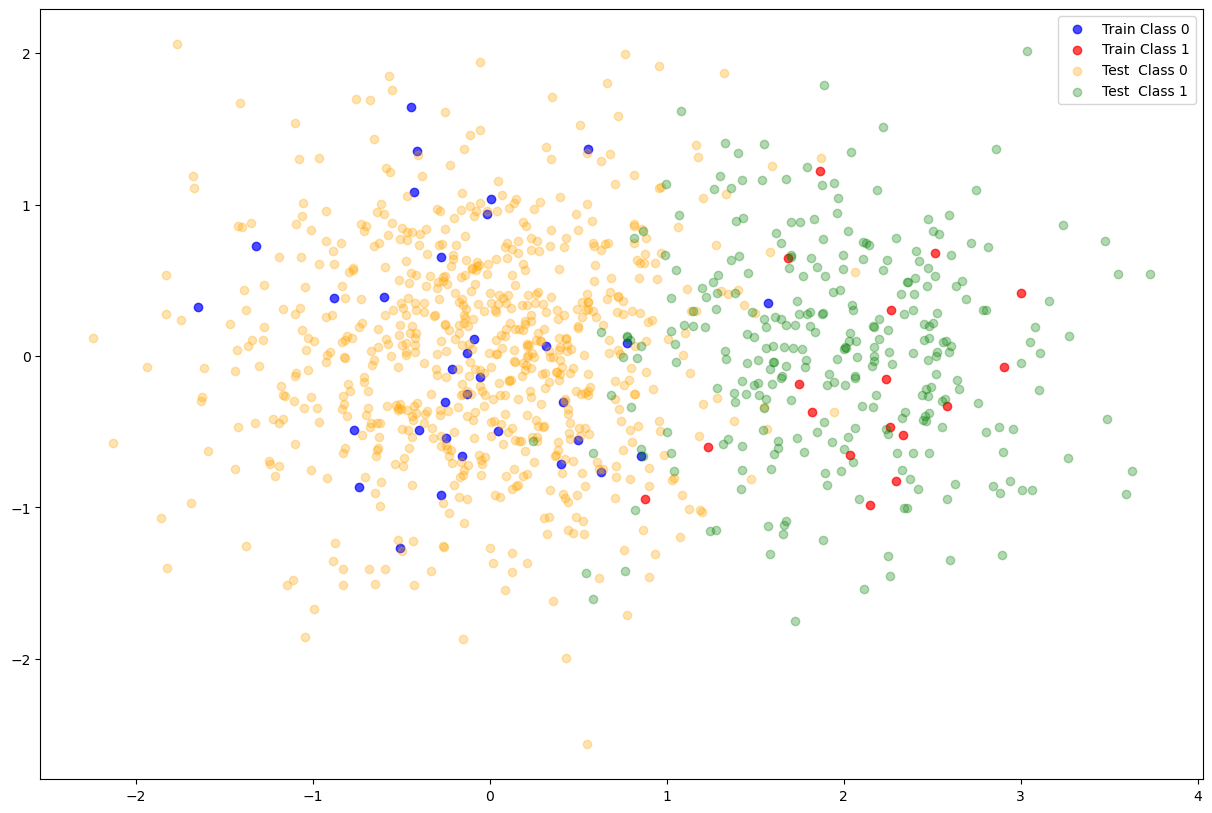

In [3]:
plt.figure(figsize=(15, 10))

# Xtrain values where the target class is 0
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='blue', label='Train Class 0', alpha=0.7 )

# Xtrain values where the target class is 1
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], color='red',  label='Train Class 1', alpha=0.7 )

# Xtest values where the target class is 0
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='orange', label='Test  Class 0', alpha=0.3 )

# Xtest values where the target class is 1
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='green', label='Test  Class 1', alpha=0.3 )

plt.axis()
plt.legend()
plt.show()

<span style="color:blue">

<br>

We observe that there is a visual separation between class 0 points and class 1 points.

<br>

<span>

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

<span style="color:blue">

In this exercice, we have that : 

$$\mathbb{P}(Y = 1) = p \quad \quad \quad \text{and} \quad \quad \quad \mathbb{P}(Y = 0) = 1-p$$

For this setting, the Bayes classifier is defined by :

$$f^\star(x) =
\begin{cases}
1 & \text{si } \quad \quad \mathbb{P}(Y=1 \mid x) > \mathbb{P}(Y=0 \mid x) \\
0 & \text{sinon}
\end{cases}$$

Using the Bayes formula, we get that :

$$ \frac{\mathbb{P}(Y = 1 \mid x)}{\mathbb{P}(Y = 0 \mid x)} \quad = \quad \frac{\mathbb{P}(x \mid Y = 1)}{\mathbb{P}(x \mid Y = 0)} \times \frac{p}{1-p} $$

<br>

The boundary is reached when $ x \in \mathbb{R}^2 $ and $ \quad \mathbb{P}(Y=1 \mid x) = \mathbb{P}(Y=0 \mid x)$

$$ \boxed{\quad \mathbb{Boundary} \quad = \quad \{x \in \mathbb{R}^2 \mid \frac{\mathbb{P}(x \mid Y = 1)}{\mathbb{P}(x \mid Y = 0)} \quad = \quad  \frac{1-p}{p} \} \quad} $$ 

<br>

<span>

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [4]:
from sklearn.base import BaseEstimator, ClassifierMixin

class BayesClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self,mu0, mu1, sigma0, sigma1, p):
        self.mu0 = mu0
        self.mu1 = mu1
        self.sigma0 = sigma0
        self.sigma1 = sigma1
        self.p = p

    def gaussian_pdf(self, X, mu, sigma):
        # We use the formula given in Step2
        det = np.linalg.det(sigma)
        inv = np.linalg.inv(sigma)
        norm = 1 / (2* np.pi * np.sqrt(det))
        diff = X - mu
        expo = np.exp(-0.5 * np.sum(diff @ inv * diff, axis=1))
        return norm * expo

    def predict(self, X):
        # Compute p0 and p1
        p0 = self.gaussian_pdf(X, self.mu0, self.sigma0)
        p1 = self.gaussian_pdf(X, self.mu1, self.sigma1)

        # Using question b, return a vector of 0 and 1
        return (p1 * self.p > p0 * (1 - self.p)).astype(int)

In [5]:
# Generation of data
X_data, y_data = generate_dataset(10000, epsilon, p)

classifier = BayesClassifier(mu0, mu1,sigma0, sigma1, p)

y_pred = classifier.predict(X_data)

error = np.mean(y_pred != y_data)
print("Bayes error:", error)

Bayes error: 0.0625


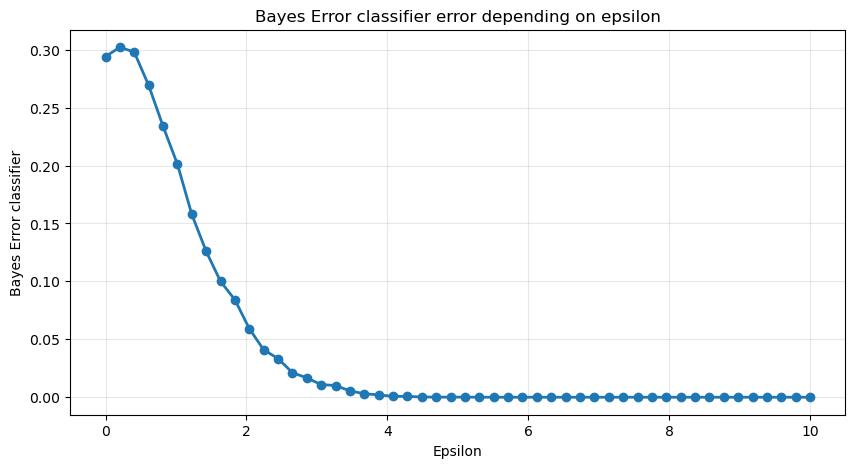

In [6]:
# Testing different values of epsilon
epsilons = np.linspace(0, 10, 50)
error_rates = []

for eps in epsilons :
    mu1 = np.array([eps, 0])
    X_data, y_data = generate_dataset(10000, eps, p)
    classifier = BayesClassifier(mu0, mu1, sigma0, sigma1, p)
    y_pred = classifier.predict(X_data)
    error = np.mean(y_pred != y_data)
    error_rates.append(error)

plt.figure(figsize=(10, 5))
plt.plot(epsilons, error_rates, 'o-', linewidth=2)
plt.xlabel('Epsilon')
plt.ylabel('Bayes Error classifier')
plt.title('Bayes Error classifier error depending on epsilon')
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:blue">

<br>

The value of $\epsilon$ determines the separation of the two Gaussian functions. In other words, the larger $\epsilon$ is, the easier it will be to distinguish between the two classes. This is precisely what we observe when testing different values of $\epsilon$.

<br>

<span>

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

<span style="color:blue">

<br>

The structure gives : two gaussian classes with different covariances. It is very similar to the scenario n°4 in the lecture 6.

<br>

This way, the classifier that seems to be the most adequate is Quadratic Discriminant Analysis (QDA). Both LDA and logistic regression performed poorly because the true decision boundary is non-linear, due to the unequal covariance matrices. When the data exhibits a complex non-linear relationship, a non-parametric method such as KNN can still give poor results if the level of smoothness is not chosen correctly. Due to the independence, Naive Bayes could also be suitable, but QDA seems to perfectly match the structure of the model generating the datasets.

<br>

<span>

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression

In [8]:
# parameters
epsilon = 2
p = 0.3
mu0 = np.array([0, 0])
mu1 = np.array([epsilon, 0])
sigma0 = np.array([[0.5, 0], [0, 0.5]])
sigma1 = np.array([[0.4, 0], [0, 0.4]])

X_train, y_train = generate_dataset(50, epsilon, p)
X_test, y_test = generate_dataset(1000, epsilon, p)

# Classifiers
classifier_LDA = LDA()
classifier_QDA = QDA()
classifier_logistic = LogisticRegression()
classifier = BayesClassifier(mu0, mu1,sigma0, sigma1, p)

# Fitting on training data
classifier_LDA.fit(X_train, y_train)
classifier_QDA.fit(X_train, y_train)
classifier_logistic.fit(X_train, y_train)

# Predicting on test data
y_pred_LDA = classifier_LDA.predict(X_test)
y_pred_QDA = classifier_QDA.predict(X_test)
y_pred_logistic = classifier_logistic.predict(X_test)
y_pred = classifier.predict(X_test)

# Errors
error_LDA = np.mean(y_test != y_pred_LDA)
error_QDA = np.mean(y_test != y_pred_QDA)
error_logistic = np.mean(y_test != y_pred_logistic)
error = np.mean(y_test != y_pred)

print(f"Bayes error: {error}")
print(f"LDA Error : {error_LDA}, Gap with Bayes error rate : {error_LDA - error} ")
print(f"QDA Error: {error_QDA}, Gap with Bayes error rate : {error_QDA - error}")
print(f"Logistic Error : {error_logistic}, Gap with Bayes error rate : {error_logistic - error}")

Bayes error: 0.062
LDA Error : 0.067, Gap with Bayes error rate : 0.0050000000000000044 
QDA Error: 0.064, Gap with Bayes error rate : 0.0020000000000000018
Logistic Error : 0.069, Gap with Bayes error rate : 0.007000000000000006


In [9]:
# Defining a pipeline
def pipeline(classifier, X_train, y_train, X_test, y_test) :
    # Bayes classifier doesn't have a fitting method
    if isinstance(classifier, (LDA, QDA, LogisticRegression)):
        classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    return np.mean(y_test != y_pred)

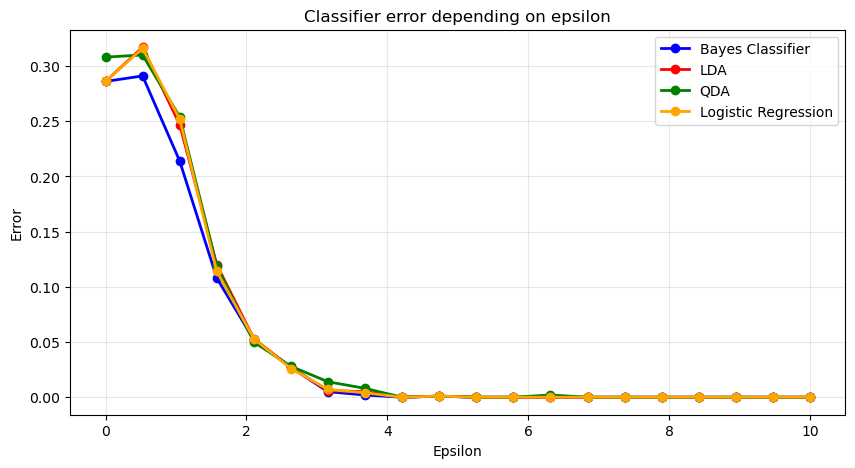

In [10]:
# Testing different values of epsilon
epsilons = np.linspace(0, 10, 20)
error_rates_bayes = []
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []

for eps in epsilons :
    mu1 = np.array([eps, 0])
    X_train, y_train = generate_dataset(50, eps, p)
    X_test, y_test = generate_dataset(1000, eps, p)
    
    # Errors
    error_bayes = pipeline(BayesClassifier(mu0, mu1, sigma0, sigma1, p), X_train, y_train, X_test, y_test)
    error_LDA = pipeline(LDA(), X_train, y_train, X_test, y_test)
    error_QDA = pipeline(QDA(), X_train, y_train, X_test, y_test)
    error_logistic = pipeline(LogisticRegression(), X_train, y_train, X_test, y_test)
    
    error_rates_bayes.append(error_bayes)
    error_rates_LDA.append(error_LDA)
    error_rates_QDA.append(error_QDA)
    error_rates_logistic.append(error_logistic)

plt.figure(figsize=(10, 5))
plt.plot(epsilons, error_rates_bayes, 'o-', linewidth=2, color="blue", label='Bayes Classifier')
plt.plot(epsilons, error_rates_LDA, 'o-', linewidth=2, color="red", label='LDA')
plt.plot(epsilons, error_rates_QDA, 'o-', linewidth=2, color="green", label='QDA')
plt.plot(epsilons, error_rates_logistic, 'o-', linewidth=2, color="orange", label='Logistic Regression')
plt.xlabel('Epsilon')
plt.ylabel('Error')
plt.title('Classifier error depending on epsilon')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:blue">

<br>

We observe that overall, the Bayesian classifier is better than the other classifiers.

<br>

<span>

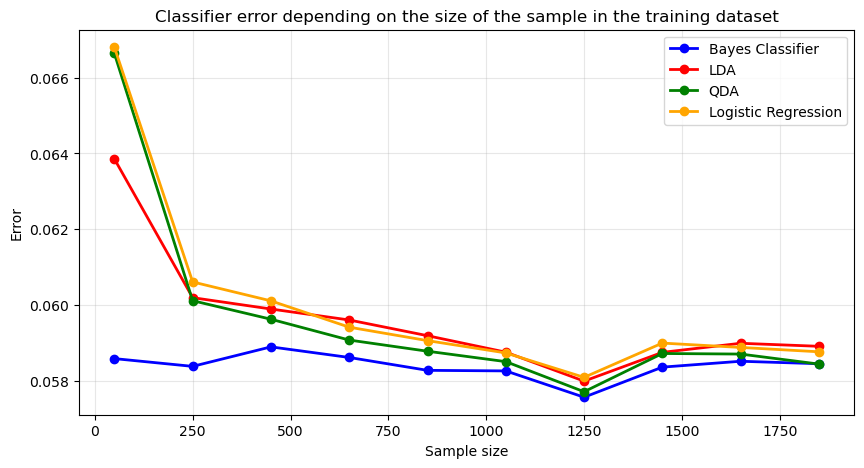

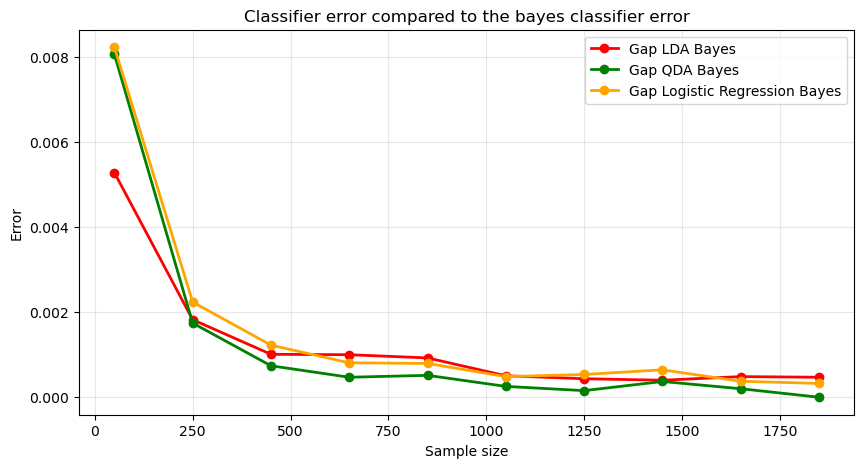

In [13]:
# Testing with more sample
samples = np.arange(50, 2050, 200)
epsilon = 2
error_rates_bayes = []
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []

for sample in samples :
    # We try to smooth the results
    errors_bayes = []
    errors_LDA = []
    errors_QDA = []
    errors_logistic = []
    for _ in range(200):
        mu1 = np.array([epsilon, 0])
        X_train, y_train = generate_dataset(sample, epsilon, p)
        X_test, y_test = generate_dataset(1000, epsilon, p)
        
        # Errors
        error_bayes = pipeline(BayesClassifier(mu0, mu1, sigma0, sigma1, p), X_train, y_train, X_test, y_test)
        error_LDA = pipeline(LDA(), X_train, y_train, X_test, y_test)
        error_QDA = pipeline(QDA(), X_train, y_train, X_test, y_test)
        error_logistic = pipeline(LogisticRegression(), X_train, y_train, X_test, y_test)
        
        errors_bayes.append(error_bayes)
        errors_LDA.append(error_LDA)
        errors_QDA.append(error_QDA)
        errors_logistic.append(error_logistic)

    error_rates_bayes.append(np.mean(errors_bayes))
    error_rates_LDA.append(np.mean(errors_LDA))
    error_rates_QDA.append(np.mean(errors_QDA))
    error_rates_logistic.append(np.mean(errors_logistic))

plt.figure(figsize=(10, 5))
plt.plot(samples, error_rates_bayes, 'o-', linewidth=2, color="blue", label='Bayes Classifier')
plt.plot(samples, error_rates_LDA, 'o-', linewidth=2, color="red", label='LDA')
plt.plot(samples, error_rates_QDA, 'o-', linewidth=2, color="green", label='QDA')
plt.plot(samples, error_rates_logistic, 'o-', linewidth=2, color="orange", label='Logistic Regression')
plt.xlabel('Sample size')
plt.ylabel('Error')
plt.title('Classifier error depending on the size of the sample in the training dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(samples, np.array(error_rates_LDA) - np.array(error_rates_bayes), 'o-', linewidth=2, color="red", label='Gap LDA Bayes')
plt.plot(samples, np.array(error_rates_QDA) - np.array(error_rates_bayes), 'o-', linewidth=2, color="green", label='Gap QDA Bayes')
plt.plot(samples, np.array(error_rates_logistic) - np.array(error_rates_bayes), 'o-', linewidth=2, color="orange", label='Gap Logistic Regression Bayes')
plt.xlabel('Sample size')
plt.ylabel('Error')
plt.title('Classifier error compared to the bayes classifier error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:blue">

<br>

In conclusion, our experiments confirm the theory: QDA is the best classifier that can asymptotically equal Bayes' error (its gap narrows as the training size increases, reflecting pure variance), while LDA and logistic regression consistently remain above Bayes due to their linear decision frontier.

<br>

<span>

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

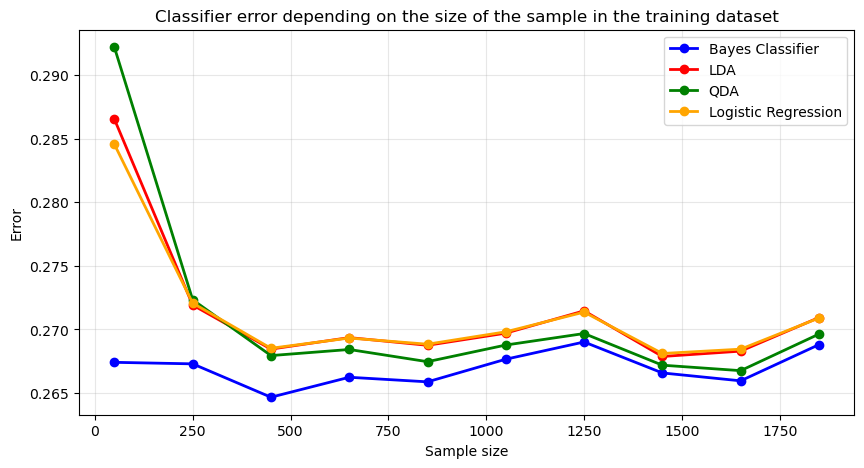

In [16]:
# Testing with more sample
samples = np.arange(50, 2050, 200)
epsilon_prime = 0.5
p_prime = 0.7
N = 1000
error_rates_bayes = []
error_rates_LDA = []
error_rates_QDA = []
error_rates_logistic = []

for sample in samples :
    # We try to smooth the results
    errors_bayes = []
    errors_LDA = []
    errors_QDA = []
    errors_logistic = []
    for _ in range(200):
        mu1 = np.array([epsilon_prime, 0])
        X_train, y_train = generate_dataset(sample, epsilon_prime, p_prime)
        X_test, y_test = generate_dataset(N, epsilon_prime, p_prime)
        
        # Errors
        error_bayes = pipeline(BayesClassifier(mu0, mu1, sigma0, sigma1, p_prime), X_train, y_train, X_test, y_test)
        error_LDA = pipeline(LDA(), X_train, y_train, X_test, y_test)
        error_QDA = pipeline(QDA(), X_train, y_train, X_test, y_test)
        error_logistic = pipeline(LogisticRegression(), X_train, y_train, X_test, y_test)
        
        errors_bayes.append(error_bayes)
        errors_LDA.append(error_LDA)
        errors_QDA.append(error_QDA)
        errors_logistic.append(error_logistic)

    error_rates_bayes.append(np.mean(errors_bayes))
    error_rates_LDA.append(np.mean(errors_LDA))
    error_rates_QDA.append(np.mean(errors_QDA))
    error_rates_logistic.append(np.mean(errors_logistic))

plt.figure(figsize=(10, 5))
plt.plot(samples, error_rates_bayes, 'o-', linewidth=2, color="blue", label='Bayes Classifier')
plt.plot(samples, error_rates_LDA, 'o-', linewidth=2, color="red", label='LDA')
plt.plot(samples, error_rates_QDA, 'o-', linewidth=2, color="green", label='QDA')
plt.plot(samples, error_rates_logistic, 'o-', linewidth=2, color="orange", label='Logistic Regression')
plt.xlabel('Sample size')
plt.ylabel('Error')
plt.title('Classifier error depending on the size of the sample in the training dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:blue">

<br>

On the new test distribution, all classifiers exhibit higher error rates because the two classes overlap much more. QDA remains the closest to Bayes, while LDA and logistic regression deteriorate significantly due to their linear decision boundaries, which cannot adapt to the new optimal quadratic frontier. These results confirm that changing the underlying data distribution affects all classifiers, but only QDA is flexible enough to track the new generative structure.

<br>

<span>

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

<span style="color:blue">

<br>

The feature engineering I chose is explained in the files `DataTreatmentTrain.ipynb`, `DataTestVisualization.ipynb` and `DataTreatmentPipeline.ipynb`.

<br>

<span>

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

<span style="color:blue">

<br>

I first tried a random forest classifier and got a score of $0.77751$ in Kaggle's public ranking.

<br>

Then, with XGBoost, I got a score of $0.78229$ in Kaggle's public ranking.

<br>

I then tried with a simple neural network model and got a score of $0.77272$ in Kaggle's public ranking.

<br>

These results were obtained without any optimization. We could try to obtain better results by refining the hyperparameters of the models.

<br>

<span>